# Asistente de Compras Inteligente para Bodegas — Notebook consolidado
### Software Inteligente — Avance 30%

Notebook único: la base de datos (SQLite) alimenta la lógica difusa, la función de fitness y el
algoritmo genético **ya validados por el profesor la semana anterior**. Al final, la mejor
recomendación que encuentra el algoritmo (no un individuo de ejemplo) se guarda de vuelta en la BD.
Ademas ya hay cargado un registro en la bd, en la celda final esta la funcion para limpiarla asi que si se nescesita correr el notebook se recomienda correr esa celda final.

## 1. Conexión a la base de datos y carga del catálogo (SQL, no hardcodeado)

In [10]:
import sqlite3
import random
import matplotlib.pyplot as plt

random.seed(42)

conn = sqlite3.connect("bodega.db")
conn.row_factory = sqlite3.Row
cur = conn.cursor()

query_catalogo = """
SELECT p.id_producto, p.nombre, c.nombre AS categoria, p.precio_compra,
       p.precio_venta, p.perecibilidad, p.dias_vida_util, p.stock_actual,
       COALESCE(SUM(v.cantidad_vendida), 0) AS ventas_4sem
FROM PRODUCTO p
JOIN CATEGORIA c ON c.id_categoria = p.id_categoria
LEFT JOIN VENTA_HISTORICA v ON v.id_producto = p.id_producto
GROUP BY p.id_producto
ORDER BY p.id_producto;
"""
productos = [dict(row) for row in cur.execute(query_catalogo)]
assert len(productos) == 15

solicitud_row = cur.execute("SELECT * FROM SOLICITUD ORDER BY id_solicitud DESC LIMIT 1").fetchone()
id_solicitud = solicitud_row["id_solicitud"]

categorias_prioritarias = [r[0] for r in cur.execute(
    """SELECT c.nombre FROM SOLICITUD_CATEGORIA_PRIORITARIA scp
        JOIN CATEGORIA c ON c.id_categoria = scp.id_categoria WHERE scp.id_solicitud=?""",
    (id_solicitud,))]
incluir_forzado = [r[0] for r in cur.execute(
    """SELECT p.nombre FROM SOLICITUD_PRODUCTO_REGLA spr
        JOIN PRODUCTO p ON p.id_producto = spr.id_producto
        WHERE spr.id_solicitud=? AND spr.tipo_regla='incluir_forzado'""",
    (id_solicitud,))]
excluir = [r[0] for r in cur.execute(
    """SELECT p.nombre FROM SOLICITUD_PRODUCTO_REGLA spr
        JOIN PRODUCTO p ON p.id_producto = spr.id_producto
        WHERE spr.id_solicitud=? AND spr.tipo_regla='excluir'""",
    (id_solicitud,))]

solicitud_usuario = {
    "presupuesto": solicitud_row["presupuesto"],
    "categorias_prioritarias": categorias_prioritarias,
    "incluir_forzado": incluir_forzado,
    "excluir": excluir,
}

print(f"Catalogo cargado desde BD: {len(productos)} productos")
print("Solicitud cargada desde BD:", solicitud_usuario)


Catalogo cargado desde BD: 15 productos
Solicitud cargada desde BD: {'presupuesto': 1500.0, 'categorias_prioritarias': ['abarrotes', 'lacteos'], 'incluir_forzado': ['Arroz'], 'excluir': []}


## 2. Lógica difusa y función de fitness

*Funciones de membresía, defuzzificación y fitness ya validadas la semana anterior — se aplican aquí directamente sobre los datos que acaban de cargarse desde la BD.*

In [11]:
def membresia_trapezoidal(x, a, b, c, d):
    if x <= a or x >= d:
        return 0.0
    if b <= x <= c:
        return 1.0
    if a < x < b:
        return (x - a) / (b - a)
    return (d - x) / (d - c)

def score_demanda(ventas):
    mu_baja  = membresia_trapezoidal(ventas, 0, 0, 5, 15)
    mu_media = membresia_trapezoidal(ventas, 5, 15, 15, 25)
    mu_alta  = membresia_trapezoidal(ventas, 15, 25, 999, 999)
    suma = mu_baja + mu_media + mu_alta
    return 0.5 if suma == 0 else (mu_baja*0.2 + mu_media*0.5 + mu_alta*0.9) / suma

def riesgo_merma(dias_vida_util):
    mu_alto  = membresia_trapezoidal(dias_vida_util, 0, 0, 3, 7)
    mu_medio = membresia_trapezoidal(dias_vida_util, 3, 7, 7, 15)
    mu_bajo  = membresia_trapezoidal(dias_vida_util, 7, 15, 999, 999)
    suma = mu_alto + mu_medio + mu_bajo
    return 0.5 if suma == 0 else (mu_alto*0.8 + mu_medio*0.5 + mu_bajo*0.2) / suma

def peso_categoria(categoria, categorias_prioritarias):
    return 1.3 if categoria in categorias_prioritarias else 1.0

FACTOR_CASTIGO = 10
PENALIZACION_RESTRICCION_DURA = 500
CANTIDAD_MIN, CANTIDAD_MAX = 0, 30

def calcular_fitness(individuo, solicitud):
    parte_positiva = parte_negativa = costo_total = 0.0
    for i, prod in enumerate(productos):
        cantidad = individuo[i]
        sd = score_demanda(prod["ventas_4sem"])
        rm = riesgo_merma(prod["dias_vida_util"])
        pc = peso_categoria(prod["categoria"], solicitud["categorias_prioritarias"])
        costo_total += cantidad * prod["precio_compra"]
        parte_positiva += cantidad * prod["precio_venta"] * sd * pc
        parte_negativa += cantidad * prod["precio_compra"] * rm

    penal_presupuesto = max(0.0, (costo_total - solicitud["presupuesto"]) * FACTOR_CASTIGO)

    cantidades = {productos[i]["nombre"]: individuo[i] for i in range(len(productos))}
    penal_restricciones = 0.0
    for nombre in solicitud["incluir_forzado"]:
        if cantidades.get(nombre, 0) == 0:
            penal_restricciones += PENALIZACION_RESTRICCION_DURA
    for nombre in solicitud["excluir"]:
        if cantidades.get(nombre, 0) > 0:
            penal_restricciones += PENALIZACION_RESTRICCION_DURA

    return parte_positiva - parte_negativa - penal_presupuesto - penal_restricciones, costo_total


## 3. Cadenas para crossover y algoritmo genético

*Padres, crossover de un punto, selección por torneo, mutación y elitismo — algoritmo ya validado la semana anterior. Parámetros: población 40, 1500 generaciones, crossover 0.8, mutación 0.08, torneo de 3, elitismo 1.*

In [12]:
padre_1 = [20, 15, 5, 30, 10, 0,  0,  8,  2,  12, 6,  0,  18, 4,  9]
padre_2 = [5,  25, 15, 5,  3,  10, 20, 15, 8,  5,  12, 15, 3,  20, 15]

def crossover_un_punto(p1, p2, punto_corte=None):
    if punto_corte is None:
        punto_corte = random.randint(1, len(p1) - 1)
    return p1[:punto_corte] + p2[punto_corte:], p2[:punto_corte] + p1[punto_corte:], punto_corte

def generar_individuo():
    individuo = [random.randint(CANTIDAD_MIN, CANTIDAD_MAX) for _ in productos]
    for i, prod in enumerate(productos):
        if prod["nombre"] in solicitud_usuario["incluir_forzado"] and individuo[i] == 0:
            individuo[i] = random.randint(1, CANTIDAD_MAX)
    return individuo

def seleccion_torneo(poblacion_evaluada, k=3):
    participantes = random.sample(poblacion_evaluada, k)
    return max(participantes, key=lambda x: x[1])[0]

def mutar(individuo, tasa=0.08):
    nuevo = individuo[:]
    for i in range(len(nuevo)):
        if random.random() < tasa:
            nuevo[i] = random.randint(CANTIDAD_MIN, CANTIDAD_MAX)
    for i, prod in enumerate(productos):
        if prod["nombre"] in solicitud_usuario["incluir_forzado"] and nuevo[i] == 0:
            nuevo[i] = random.randint(1, CANTIDAD_MAX)
    return nuevo

TAMANO_POBLACION, GENERACIONES = 40, 1500
TASA_CROSSOVER, TAMANO_TORNEO, ELITISMO = 0.8, 3, 1

poblacion = [generar_individuo() for _ in range(TAMANO_POBLACION)]
poblacion[0], poblacion[1] = padre_1[:], padre_2[:]

historial_mejor_fitness = []
mejor_individuo_global = None
mejor_fitness_global = float("-inf")
costo_mejor_global = None

for gen in range(GENERACIONES):
    evaluada = [(ind, *calcular_fitness(ind, solicitud_usuario)) for ind in poblacion]
    evaluada_fit = [(ind, fit) for ind, fit, costo in evaluada]
    evaluada.sort(key=lambda x: x[1], reverse=True)

    if evaluada[0][1] > mejor_fitness_global:
        mejor_fitness_global = evaluada[0][1]
        mejor_individuo_global = evaluada[0][0][:]
        costo_mejor_global = evaluada[0][2]

    historial_mejor_fitness.append(evaluada[0][1])

    nueva_poblacion = [ind for ind, _, _ in evaluada[:ELITISMO]]
    evaluada_para_torneo = [(ind, fit) for ind, fit, _ in evaluada]

    while len(nueva_poblacion) < TAMANO_POBLACION:
        pa = seleccion_torneo(evaluada_para_torneo, TAMANO_TORNEO)
        pb = seleccion_torneo(evaluada_para_torneo, TAMANO_TORNEO)
        if random.random() < TASA_CROSSOVER:
            ha, hb, _ = crossover_un_punto(pa, pb)
        else:
            ha, hb = pa[:], pb[:]
        nueva_poblacion.append(mutar(ha))
        if len(nueva_poblacion) < TAMANO_POBLACION:
            nueva_poblacion.append(mutar(hb))

    poblacion = nueva_poblacion

print(f"Simulacion completa: {GENERACIONES} generaciones (datos desde BD)")
print(f"Mejor fitness: {mejor_fitness_global:.2f}")
print(f"Costo total: S/ {costo_mejor_global:.2f}  (presupuesto: S/ {solicitud_usuario['presupuesto']})")
print(f"Diferencia vs presupuesto: S/ {solicitud_usuario['presupuesto'] - costo_mejor_global:.2f}")
print(f"Mejor individuo: {mejor_individuo_global}")


Simulacion completa: 1500 generaciones (datos desde BD)
Mejor fitness: 930.71
Costo total: S/ 1499.70  (presupuesto: S/ 1500.0)
Diferencia vs presupuesto: S/ 0.30
Mejor individuo: [30, 30, 30, 30, 30, 0, 19, 30, 1, 28, 29, 0, 27, 30, 30]


### Gráfico de convergencia

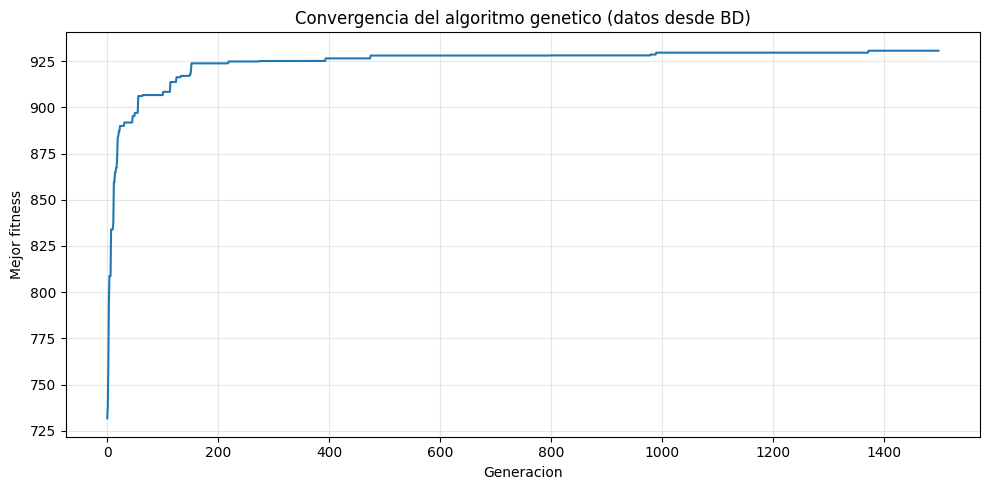

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(historial_mejor_fitness)
plt.title("Convergencia del algoritmo genetico (datos desde BD)")
plt.xlabel("Generacion")
plt.ylabel("Mejor fitness")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Guardar la mejor recomendación encontrada en la BD (RECOMENDACION + DETALLE_RECOMENDACION)

Se guarda el individuo que realmente ganó las 1500 generaciones — no un individuo de ejemplo.

In [14]:
explicacion = (
    f"Con tu presupuesto de S/{solicitud_usuario['presupuesto']:.0f}, priorizando "
    f"{' y '.join(solicitud_usuario['categorias_prioritarias'])}, la canasta optimizada usa "
    f"S/{costo_mejor_global:.2f} del presupuesto, maximizando productos de alta demanda y "
    f"minimizando el riesgo de merma en perecibles."
)

cur.execute(
    """INSERT INTO RECOMENDACION (id_solicitud, fecha, fitness_final, costo_total, explicacion_texto)
        VALUES (?,?,?,?,?)""",
    (id_solicitud, "2026-09-21", mejor_fitness_global, costo_mejor_global, explicacion),
)
id_recomendacion = cur.lastrowid

for i, prod in enumerate(productos):
    if mejor_individuo_global[i] > 0:
        cur.execute(
            """INSERT INTO DETALLE_RECOMENDACION (id_recomendacion, id_producto, cantidad_recomendada)
                VALUES (?,?,?)""",
            (id_recomendacion, prod["id_producto"], mejor_individuo_global[i]),
        )

conn.commit()
print(f"Recomendacion #{id_recomendacion} guardada (fitness {mejor_fitness_global:.2f}, costo S/{costo_mejor_global:.2f})")


Recomendacion #3 guardada (fitness 930.71, costo S/1499.70)


### Verificación final: leer la recomendación tal como la mostraría la GUI

In [15]:
rec = cur.execute("SELECT * FROM RECOMENDACION WHERE id_recomendacion=?", (id_recomendacion,)).fetchone()
print(f"Fitness: {rec['fitness_final']:.2f}   Costo total: S/ {rec['costo_total']:.2f}")
print(f"Explicacion: {rec['explicacion_texto']}\n")

detalle = cur.execute(
    """SELECT p.nombre, d.cantidad_recomendada
        FROM DETALLE_RECOMENDACION d JOIN PRODUCTO p ON p.id_producto = d.id_producto
        WHERE d.id_recomendacion = ?""",
    (id_recomendacion,))
for r in detalle:
    print(f"  {r['nombre']:<24} -> {r['cantidad_recomendada']} unidades")

conn.close()


Fitness: 930.71   Costo total: S/ 1499.70
Explicacion: Con tu presupuesto de S/1500, priorizando abarrotes y lacteos, la canasta optimizada usa S/1499.70 del presupuesto, maximizando productos de alta demanda y minimizando el riesgo de merma en perecibles.

  Arroz                    -> 30 unidades
  Leche Gloria 1L          -> 30 unidades
  Aceite                   -> 30 unidades
  Fideos                   -> 30 unidades
  Atún                     -> 30 unidades
  Yogurt Gloria            -> 19 unidades
  Gaseosa Coca-Cola 1.5L   -> 30 unidades
  Detergente               -> 1 unidades
  Galletas Oreo            -> 28 unidades
  Huevos (docena)          -> 29 unidades
  Azúcar                   -> 27 unidades
  Papas Lay's              -> 30 unidades
  Inca Kola 1.5L           -> 30 unidades


## Conclusión

La base de datos alimenta directamente la lógica difusa, el fitness y el algoritmo genético (ya
validados), y el resultado final —la mejor canasta encontrada en 1500 generaciones, ajustada casi
al límite del presupuesto— queda guardado en `RECOMENDACION` / `DETALLE_RECOMENDACION`, listo para
que la GUI lo consulte.

## Limpieza opcional de la recomendación

La siguiente celda está comentada para evitar borrar datos accidentalmente.
Si deseas eliminar la recomendación guardada y sus detalles, quita el signo `#` de cada línea de la celda siguiente y ejecútala.

In [16]:
# Limpieza opcional: elimina la recomendacion guardada y sus detalles.
# Para ejecutar esta limpieza, selecciona toda la celda y presiona Ctrl + /.
# import sqlite3

# try:
#     conn_limpieza = conn
#     conn_limpieza.execute("SELECT 1")
#     conn_limpieza.rollback()
#     cerrar_conexion = False
# except (NameError, sqlite3.ProgrammingError):
#     conn_limpieza = sqlite3.connect("bodega.db", timeout=10)
#     cerrar_conexion = True

# cur_limpieza = conn_limpieza.cursor()
# recomendacion = cur_limpieza.execute(
#     "SELECT id_recomendacion FROM RECOMENDACION ORDER BY id_recomendacion DESC LIMIT 1"
# ).fetchone()

# if recomendacion is None:
#     print("No hay recomendaciones para eliminar.")
# else:
#     id_recomendacion_eliminar = recomendacion[0]
#     cur_limpieza.execute(
#         "DELETE FROM DETALLE_RECOMENDACION WHERE id_recomendacion = ?",
#         (id_recomendacion_eliminar,),
#     )
#     cur_limpieza.execute(
#         "DELETE FROM RECOMENDACION WHERE id_recomendacion = ?",
#         (id_recomendacion_eliminar,),
#     )
#     conn_limpieza.commit()
#     print(f"Recomendacion #{id_recomendacion_eliminar} y sus detalles fueron eliminados.")

# if cerrar_conexion:
#     conn_limpieza.close()